Linear Regression R2 Score:
0.978177356243559
Linear Regression MAE:
2575.4867731294835

Decision Tree R2 Score:
0.952429817155044
Decision Tree MAE:
3152.6315789473683

Random Forest R2 Score:
0.9208116359408742
Random Forest MAE:
4205.013157894736


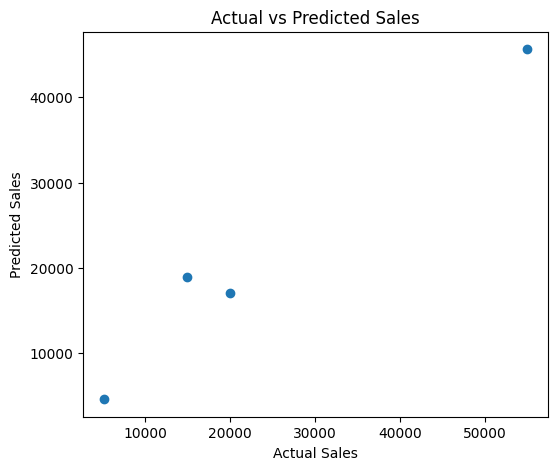

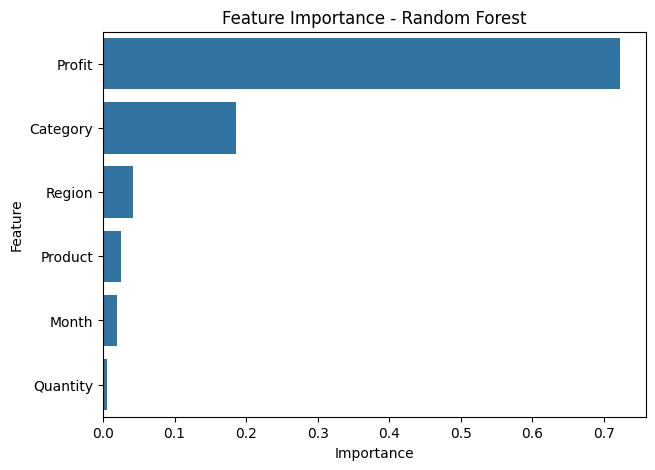

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, r2_score

# LOAD DATA
df = pd.read_csv("/content/sales_data.csv")

# DATA CLEANING
# Fill missing Sales values
df['Sales'] = df['Sales'].fillna(df['Sales'].mean())

# Remove duplicates
df = df.drop_duplicates()

# Convert Date
df['Date'] = pd.to_datetime(df['Date'])

# Create Month column
df['Month'] = df['Date'].dt.month


# ENCODE CATEGORICAL DATA

encoder = LabelEncoder()

df['Region'] = encoder.fit_transform(df['Region'])
df['Product'] = encoder.fit_transform(df['Product'])
df['Category'] = encoder.fit_transform(df['Category'])

# FEATURES AND TARGET

X = df[['Region', 'Product', 'Category', 'Quantity', 'Profit', 'Month']]

y = df['Sales']


# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
# LINEAR REGRESSION

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Linear Regression R2 Score:")
print(r2_score(y_test, lr_pred))

print("Linear Regression MAE:")
print(mean_absolute_error(y_test, lr_pred))

# DECISION TREE

dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("\nDecision Tree R2 Score:")
print(r2_score(y_test, dt_pred))

print("Decision Tree MAE:")
print(mean_absolute_error(y_test, dt_pred))

# RANDOM FOREST

rf_model = RandomForestRegressor(random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("\nRandom Forest R2 Score:")
print(r2_score(y_test, rf_pred))

print("Random Forest MAE:")
print(mean_absolute_error(y_test, rf_pred))


# VISUALIZATION
# Actual vs Predicted (Random Forest)

plt.figure(figsize=(6,5))

plt.scatter(y_test, rf_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()

# FEATURE IMPORTANCE
importance = rf_model.feature_importances_

feature_names = X.columns

feature_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

feature_df = feature_df.sort_values(by='Importance', ascending=False)

# Plot feature importance

plt.figure(figsize=(7,5))

sns.barplot(x='Importance', y='Feature', data=feature_df)

plt.title("Feature Importance - Random Forest")

plt.show()